<a href="https://colab.research.google.com/github/SakshiMaholiya123/Machine-Learning/blob/project/_02_Loan_Portfolio_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [157]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [158]:
file=pd.read_csv('hdfc_loan_dataset_full_enriched - hdfc_loan_dataset_full_enriched.csv')

In [159]:
file.head()

,Loan_ID,Bank,Customer_Name,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,...,Loan_to_Annual_Income,Customer_Sentiment,Religion,State,City,PIN_Code,Aadhaar_Synthetic,Phone_Number,Email,Occupation
0,HDFC100001,HDFC Bank,Rohan Verma,Male,No,2,Graduate,Salaried,56976,0,...,11.747,Positive,Hindu,Delhi,Dwarka,857743,6.940000e+11,9068671773,rohan.verma@example.in,Farmer
1,HDFC100002,HDFC Bank,Rohan Verma,Male,No,0,Graduate,Unemployed,1856,0,...,40.381,Negative,Hindu,Punjab,Ludhiana,863836,6.330000e+11,9990772625,rohan.verma@example.in,Civil Engineer
2,HDFC100003,HDFC Bank,Aditya Nair,Female,Yes,0,Graduate,Salaried,64553,0,...,3.082,Positive,Hindu,Maharashtra,Nagpur,834796,1.660000e+11,9195085016,aditya.nair@example.in,Medical Representative
3,HDFC100004,HDFC Bank,Ananya Joshi,Male,No,0,Graduate,Salaried,88450,0,...,0.621,Negative,Hindu,Gujarat,Vadodara,438590,5.528183e+10,9179335548,ananya.joshi@example.in,Marketing Executive
4,HDFC100005,HDFC Bank,Harpreet Singh,Male,Yes,3,Graduate,Self-Employed,9539,0,...,1.736,Neutral,Sikh,West Bengal,Kolkata,495224,1.560000e+11,9795137116,harpreet.singh@example.in,Shopkeeper


In [160]:
file['Monthly_Income']=file['Applicant_Income']+file['Coapplicant_Income']
file

,Loan_ID,Bank,Customer_Name,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,...,Customer_Sentiment,Religion,State,City,PIN_Code,Aadhaar_Synthetic,Phone_Number,Email,Occupation,Monthly_Income
0,HDFC100001,HDFC Bank,Rohan Verma,Male,No,2,Graduate,Salaried,56976,0,...,Positive,Hindu,Delhi,Dwarka,857743,6.940000e+11,9068671773,rohan.verma@example.in,Farmer,56976
1,HDFC100002,HDFC Bank,Rohan Verma,Male,No,0,Graduate,Unemployed,1856,0,...,Negative,Hindu,Punjab,Ludhiana,863836,6.330000e+11,9990772625,rohan.verma@example.in,Civil Engineer,1856
2,HDFC100003,HDFC Bank,Aditya Nair,Female,Yes,0,Graduate,Salaried,64553,0,...,Positive,Hindu,Maharashtra,Nagpur,834796,1.660000e+11,9195085016,aditya.nair@example.in,Medical Representative,64553
3,HDFC100004,HDFC Bank,Ananya Joshi,Male,No,0,Graduate,Salaried,88450,0,...,Negative,Hindu,Gujarat,Vadodara,438590,5.528183e+10,9179335548,ananya.joshi@example.in,Marketing Executive,88450
4,HDFC100005,HDFC Bank,Harpreet Singh,Male,Yes,3,Graduate,Self-Employed,9539,0,...,Neutral,Sikh,West Bengal,Kolkata,495224,1.560000e+11,9795137116,harpreet.singh@example.in,Shopkeeper,9539
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,HDFC100996,HDFC Bank,Simran Kaur,Male,Yes,1,Graduate,Salaried,44713,0,...,Neutral,Sikh,Tamil Nadu,Coimbatore,6635,3.830000e+11,9350952889,simran.kaur@example.in,Medical Representative,44713
996,HDFC100997,HDFC Bank,Krishna Mehta,Male,No,2,Graduate,Salaried,70886,0,...,Negative,Hindu,Kerala,Trivandrum,217843,7.040000e+11,9176504718,krishna.mehta@example.in,Customer Support Executive,70886
997,HDFC100998,HDFC Bank,Rohan Verma,Female,No,1,Graduate,Salaried,24392,11337,...,Positive,Hindu,Delhi,New Delhi,89211,9.954289e+10,9966866798,rohan.verma@example.in,Driver,35729
998,HDFC100999,HDFC Bank,Ananya Joshi,Female,No,2,Graduate,Salaried,64803,94136,...,Negative,Hindu,Gujarat,Ahmedabad,532976,6.170000e+11,9103847156,ananya.joshi@example.in,Electrician,158939


In [161]:
columns=['Loan_Amount','Loan_Term_Months','Existing_EMIs','Monthly_Income'].copy()

In [162]:
df=file[columns].reset_index()

Mathematical Objective
Define a Portfolio Utility Function:
U = Revenue - Risk
Find:
\frac{dU}{dL}
where:
L = Loan Amount
The goal is to locate the optimal loan range.


In [163]:
df['Annual_interest']=(df['Loan_Amount']*12*1)/100
df

,index,Loan_Amount,Loan_Term_Months,Existing_EMIs,Monthly_Income,Annual_interest
0,0,8031545,360,5610,56976,963785.40
1,1,899361,240,9166,1856,107923.32
2,2,2387748,60,0,64553,286529.76
3,3,658856,12,26613,88450,79062.72
4,4,198671,36,0,9539,23840.52
...,...,...,...,...,...,...
995,995,5883603,360,5165,44713,706032.36
996,996,2780228,300,20102,70886,333627.36
997,997,301249,24,34514,35729,36149.88
998,998,719891,48,34000,158939,86386.92


In [164]:
bank_revenue=df['Annual_interest'].sum()
bank_revenue

np.float64(266005548.12)

In [165]:
existing_risk=df['Existing_EMIs'].sum()*12
existing_risk

np.int64(218080680)

In [166]:
df['U']=df['Annual_interest']-df['Existing_EMIs']*12
df


,index,Loan_Amount,Loan_Term_Months,Existing_EMIs,Monthly_Income,Annual_interest,U
0,0,8031545,360,5610,56976,963785.40,896465.40
1,1,899361,240,9166,1856,107923.32,-2068.68
2,2,2387748,60,0,64553,286529.76,286529.76
3,3,658856,12,26613,88450,79062.72,-240293.28
4,4,198671,36,0,9539,23840.52,23840.52
...,...,...,...,...,...,...,...
995,995,5883603,360,5165,44713,706032.36,644052.36
996,996,2780228,300,20102,70886,333627.36,92403.36
997,997,301249,24,34514,35729,36149.88,-378018.12
998,998,719891,48,34000,158939,86386.92,-321613.08


In [167]:
df['du']=df['U'].diff()
df['dl']=df['Loan_Amount'].diff()
df['dU_dL']=df['du']/df['dl']
df

,index,Loan_Amount,Loan_Term_Months,Existing_EMIs,Monthly_Income,Annual_interest,U,du,dl,dU_dL
0,0,8031545,360,5610,56976,963785.40,896465.40,NaN,NaN,NaN
1,1,899361,240,9166,1856,107923.32,-2068.68,-898534.08,-7132184.0,0.125983
2,2,2387748,60,0,64553,286529.76,286529.76,288598.44,1488387.0,0.193900
3,3,658856,12,26613,88450,79062.72,-240293.28,-526823.04,-1728892.0,0.304717
4,4,198671,36,0,9539,23840.52,23840.52,264133.80,-460185.0,-0.573973
...,...,...,...,...,...,...,...,...,...,...
995,995,5883603,360,5165,44713,706032.36,644052.36,582583.92,5142366.0,0.113291
996,996,2780228,300,20102,70886,333627.36,92403.36,-551649.00,-3103375.0,0.177758
997,997,301249,24,34514,35729,36149.88,-378018.12,-470421.48,-2478979.0,0.189764
998,998,719891,48,34000,158939,86386.92,-321613.08,56405.04,418642.0,0.134733


Tasks


ask 1
Create an affordability metric.
Example:
Affordability Ratio = Monthly Obligations / Monthly Income


In [168]:
monthly_obligation=df['Annual_interest']/12
df['Affordability_ratio']=(monthly_obligation+df['Existing_EMIs'])/df['Monthly_Income']
df

,index,Loan_Amount,Loan_Term_Months,Existing_EMIs,Monthly_Income,Annual_interest,U,du,dl,dU_dL,Affordability_ratio
0,0,8031545,360,5610,56976,963785.40,896465.40,NaN,NaN,NaN,1.508099
1,1,899361,240,9166,1856,107923.32,-2068.68,-898534.08,-7132184.0,0.125983,9.784273
2,2,2387748,60,0,64553,286529.76,286529.76,288598.44,1488387.0,0.193900,0.369890
3,3,658856,12,26613,88450,79062.72,-240293.28,-526823.04,-1728892.0,0.304717,0.375371
4,4,198671,36,0,9539,23840.52,23840.52,264133.80,-460185.0,-0.573973,0.208272
...,...,...,...,...,...,...,...,...,...,...,...
995,995,5883603,360,5165,44713,706032.36,644052.36,582583.92,5142366.0,0.113291,1.431374
996,996,2780228,300,20102,70886,333627.36,92403.36,-551649.00,-3103375.0,0.177758,0.675793
997,997,301249,24,34514,35729,36149.88,-378018.12,-470421.48,-2478979.0,0.189764,1.050309
998,998,719891,48,34000,158939,86386.92,-321613.08,56405.04,418642.0,0.134733,0.259212


Task 2
Create revenue estimates for different loan ranges.


In [169]:
np.min(np.array(df['Loan_Amount']))

np.int64(1884)

In [170]:
np.max(np.array(df['Loan_Amount']))

np.int64(13790960)

In [171]:
df['Loan_range']=pd.cut(df['Loan_Amount'],bins=[1000,200000,800000,1500000,float(np.inf)],labels=['small','medium','large','very large'])
df

,index,Loan_Amount,Loan_Term_Months,Existing_EMIs,Monthly_Income,Annual_interest,U,du,dl,dU_dL,Affordability_ratio,Loan_range
0,0,8031545,360,5610,56976,963785.40,896465.40,NaN,NaN,NaN,1.508099,very large
1,1,899361,240,9166,1856,107923.32,-2068.68,-898534.08,-7132184.0,0.125983,9.784273,large
2,2,2387748,60,0,64553,286529.76,286529.76,288598.44,1488387.0,0.193900,0.369890,very large
3,3,658856,12,26613,88450,79062.72,-240293.28,-526823.04,-1728892.0,0.304717,0.375371,medium
4,4,198671,36,0,9539,23840.52,23840.52,264133.80,-460185.0,-0.573973,0.208272,small
...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,5883603,360,5165,44713,706032.36,644052.36,582583.92,5142366.0,0.113291,1.431374,very large
996,996,2780228,300,20102,70886,333627.36,92403.36,-551649.00,-3103375.0,0.177758,0.675793,very large
997,997,301249,24,34514,35729,36149.88,-378018.12,-470421.48,-2478979.0,0.189764,1.050309,medium
998,998,719891,48,34000,158939,86386.92,-321613.08,56405.04,418642.0,0.134733,0.259212,medium


In [172]:
interest_rate=12
df['revenue']=(np.array(df['Loan_Amount'])*interest_rate*1)/100
df

,index,Loan_Amount,Loan_Term_Months,Existing_EMIs,Monthly_Income,Annual_interest,U,du,dl,dU_dL,Affordability_ratio,Loan_range,revenue
0,0,8031545,360,5610,56976,963785.40,896465.40,NaN,NaN,NaN,1.508099,very large,963785.40
1,1,899361,240,9166,1856,107923.32,-2068.68,-898534.08,-7132184.0,0.125983,9.784273,large,107923.32
2,2,2387748,60,0,64553,286529.76,286529.76,288598.44,1488387.0,0.193900,0.369890,very large,286529.76
3,3,658856,12,26613,88450,79062.72,-240293.28,-526823.04,-1728892.0,0.304717,0.375371,medium,79062.72
4,4,198671,36,0,9539,23840.52,23840.52,264133.80,-460185.0,-0.573973,0.208272,small,23840.52
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,5883603,360,5165,44713,706032.36,644052.36,582583.92,5142366.0,0.113291,1.431374,very large,706032.36
996,996,2780228,300,20102,70886,333627.36,92403.36,-551649.00,-3103375.0,0.177758,0.675793,very large,333627.36
997,997,301249,24,34514,35729,36149.88,-378018.12,-470421.48,-2478979.0,0.189764,1.050309,medium,36149.88
998,998,719891,48,34000,158939,86386.92,-321613.08,56405.04,418642.0,0.134733,0.259212,medium,86386.92


In [173]:
revenue_by_range=df.groupby('Loan_range')['revenue'].sum()
revenue_by_range

/tmp/ipykernel_1354/604255748.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_by_range=df.groupby('Loan_range')['revenue'].sum()


,revenue
Loan_range,
small,1.637388e+06
medium,1.808989e+07
large,1.764863e+07
very large,2.286296e+08


Task 3
Create a utility function balancing:
Revenue,
Affordability,
Risk


In [174]:
df['norm_revenue']=(df['revenue']-df['revenue'].min())/(df['revenue'].max()-df['revenue'].min())
df_finite = df[np.isfinite(df['Affordability_ratio'])].copy()
df_finite
df['norm_affordibility']=(df_finite['Affordability_ratio']-df_finite['Affordability_ratio'].min())/(df_finite['Affordability_ratio'].max()-df_finite['Affordability_ratio'].min())
df['utility']=df['norm_affordibility']-df['norm_revenue']
df

,index,Loan_Amount,Loan_Term_Months,Existing_EMIs,Monthly_Income,Annual_interest,U,du,dl,dU_dL,Affordability_ratio,Loan_range,revenue,norm_revenue,norm_affordibility,utility
0,0,8031545,360,5610,56976,963785.40,896465.40,NaN,NaN,NaN,1.508099,very large,963785.40,0.582320,0.010923,-0.571398
1,1,899361,240,9166,1856,107923.32,-2068.68,-898534.08,-7132184.0,0.125983,9.784273,large,107923.32,0.065086,0.070906,0.005820
2,2,2387748,60,0,64553,286529.76,286529.76,288598.44,1488387.0,0.193900,0.369890,very large,286529.76,0.173026,0.002673,-0.170352
3,3,658856,12,26613,88450,79062.72,-240293.28,-526823.04,-1728892.0,0.304717,0.375371,medium,79062.72,0.047644,0.002713,-0.044931
4,4,198671,36,0,9539,23840.52,23840.52,264133.80,-460185.0,-0.573973,0.208272,small,23840.52,0.014271,0.001502,-0.012769
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,5883603,360,5165,44713,706032.36,644052.36,582583.92,5142366.0,0.113291,1.431374,very large,706032.36,0.426549,0.010367,-0.416182
996,996,2780228,300,20102,70886,333627.36,92403.36,-551649.00,-3103375.0,0.177758,0.675793,very large,333627.36,0.201489,0.004890,-0.196598
997,997,301249,24,34514,35729,36149.88,-378018.12,-470421.48,-2478979.0,0.189764,1.050309,medium,36149.88,0.021710,0.007605,-0.014105
998,998,719891,48,34000,158939,86386.92,-321613.08,56405.04,418642.0,0.134733,0.259212,medium,86386.92,0.052071,0.001871,-0.050199


Task 4
Compute first derivatives using numerical methods.


In [175]:
df['first_derivative']=np.gradient(df['U'],df['Loan_Amount'])
df

,index,Loan_Amount,Loan_Term_Months,Existing_EMIs,Monthly_Income,Annual_interest,U,du,dl,dU_dL,Affordability_ratio,Loan_range,revenue,norm_revenue,norm_affordibility,utility,first_derivative
0,0,8031545,360,5610,56976,963785.40,896465.40,NaN,NaN,NaN,1.508099,very large,963785.40,0.582320,0.010923,-0.571398,0.125983
1,1,899361,240,9166,1856,107923.32,-2068.68,-898534.08,-7132184.0,0.125983,9.784273,large,107923.32,0.065086,0.070906,0.005820,0.211811
2,2,2387748,60,0,64553,286529.76,286529.76,288598.44,1488387.0,0.193900,0.369890,very large,286529.76,0.173026,0.002673,-0.170352,-0.491901
3,3,658856,12,26613,88450,79062.72,-240293.28,-526823.04,-1728892.0,0.304717,0.375371,medium,79062.72,0.047644,0.002713,-0.044931,-0.389256
4,4,198671,36,0,9539,23840.52,23840.52,264133.80,-460185.0,-0.573973,0.208272,small,23840.52,0.014271,0.001502,-0.012769,-0.714857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,5883603,360,5165,44713,706032.36,644052.36,582583.92,5142366.0,0.113291,1.431374,very large,706032.36,0.426549,0.010367,-0.416182,0.275877
996,996,2780228,300,20102,70886,333627.36,92403.36,-551649.00,-3103375.0,0.177758,0.675793,very large,333627.36,0.201489,0.004890,-0.196598,0.184432
997,997,301249,24,34514,35729,36149.88,-378018.12,-470421.48,-2478979.0,0.189764,1.050309,medium,36149.88,0.021710,0.007605,-0.014105,0.123552
998,998,719891,48,34000,158939,86386.92,-321613.08,56405.04,418642.0,0.134733,0.259212,medium,86386.92,0.052071,0.001871,-0.050199,0.756280


Visualizations

Visual 1
Loan Amount Distribution


Text(0.5, 1.0, 'loan amount distribution')

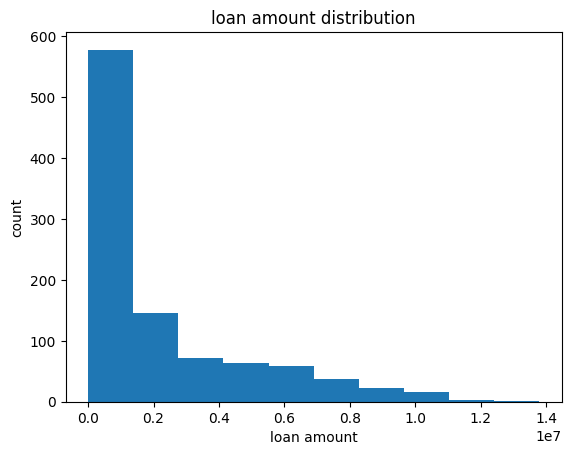

In [176]:
plt.hist(df['Loan_Amount'])
plt.xlabel('loan amount')
plt.ylabel('count')
plt.title('loan amount distribution')

Visual 2
Affordability Ratio Distribution


Text(0.5, 1.0, 'affordability ratio distribution')

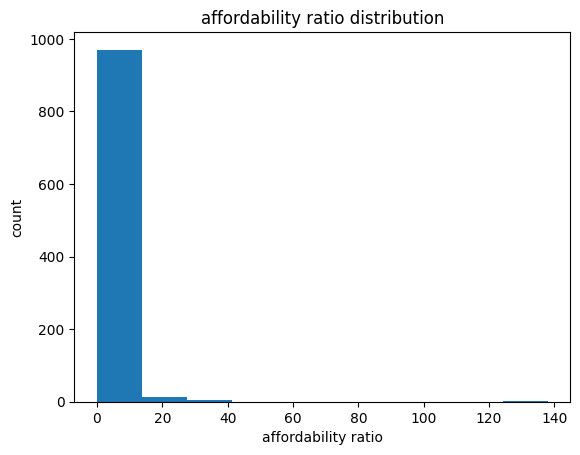

In [177]:

plt.hist(df_finite['Affordability_ratio'])
plt.xlabel('affordability ratio')
plt.ylabel('count')
plt.title('affordability ratio distribution')

Visual 3
Utility Function Curve


Text(0.5, 1.0, 'utility function curve')

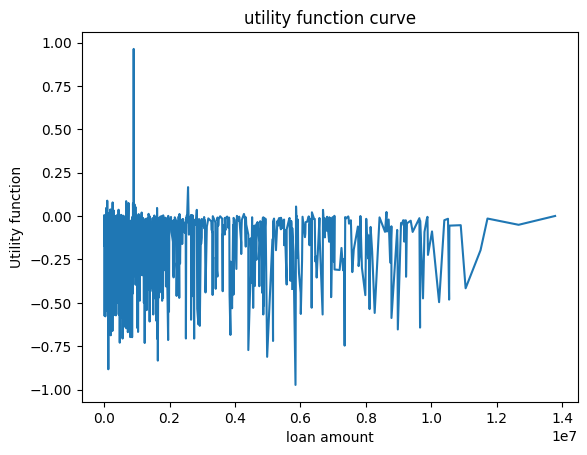

In [178]:
plt.plot(df['Loan_Amount'].sort_values(),df['utility'])
plt.xlabel('loan amount')
plt.ylabel('Utility function')
plt.title('utility function curve')
